# Annexin V Assembly Dynamics on Lipid Bilayers — High-Speed AFM

**Zenodo dataset:** https://zenodo.org/records/19254504  
**Authors:** George R. Heath (University of Leeds)  
**License:** CC-BY 4.0

HS-AFM image stacks of Annexin V assembling on DOPC:DOPS (8:2) supported lipid bilayers,
acquired with a NanoRacer (Bruker) using USC-F1.2-k0.15 cantilevers.

---
**Biological stages:**

| Stage | Description |
|-------|-------------|
| Diffusing annexin | Individual molecules freely diffusing on the bilayer |
| Lattice appears | First signs of ordered 2D lattice nucleation |
| Lattice assembly | Dynamic growth of the protein lattice |
| Lattice | Fully assembled stable 2D Annexin V lattice |

### Requirements
```bash
pip install playnano matplotlib tqdm requests pillow tifffile
```

In [1]:
pip install playnano

Note: you may need to restart the kernel to use updated packages.


## 0 · Imports & setup

In [2]:
import sys, zipfile, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Imports OK')

Imports OK


## 1 · Dataset metadata

All 37 stacks from the Zenodo record with scan parameters and stage labels.

In [3]:
import pandas as pd

STACK_META = {
    'imaging-13.08.28.653': {'note': 'diffusing annexin', 'fps': 0.78,  'scan_nm': 600,  'frames': 7,    'ypx': 256, 'xpx': 256},
    'imaging-13.26.46.569': {'note': 'diffusing annexin', 'fps': 1.56,  'scan_nm': 100,  'frames': 81,   'ypx': 256, 'xpx': 256},
    'imaging-13.30.11.268': {'note': 'diffusing annexin', 'fps': 1.56,  'scan_nm': 200,  'frames': 8,    'ypx': 256, 'xpx': 256},
    'imaging-13.37.48.575': {'note': 'diffusing annexin', 'fps': 0.78,  'scan_nm': 400,  'frames': 7,    'ypx': 512, 'xpx': 512},
    'imaging-13.46.35.510': {'note': 'lattice appears',   'fps': 0.78,  'scan_nm': 350,  'frames': 59,   'ypx': 512, 'xpx': 512},
    'imaging-13.47.52.797': {'note': 'lattice assembly',  'fps': 0.78,  'scan_nm': 200,  'frames': 9,    'ypx': 512, 'xpx': 512},
    'imaging-13.48.05.546': {'note': 'lattice assembly',  'fps': 1.56,  'scan_nm': 200,  'frames': 41,   'ypx': 256, 'xpx': 256},
    'imaging-13.48.42.653': {'note': 'lattice assembly',  'fps': 0.78,  'scan_nm': 200,  'frames': 36,   'ypx': 256, 'xpx': 256},
    'imaging-13.49.30.677': {'note': 'lattice assembly',  'fps': 1.56,  'scan_nm': 200,  'frames': 17,   'ypx': 256, 'xpx': 256},
    'imaging-13.49.42.515': {'note': 'lattice assembly',  'fps': 2.73,  'scan_nm': 200,  'frames': 100,  'ypx': 256, 'xpx': 256},
    'imaging-13.51.38.236': {'note': 'lattice assembly',  'fps': 12.50, 'scan_nm': 200,  'frames': 75,   'ypx': 128, 'xpx': 128},
    'imaging-13.51.54.501': {'note': 'lattice assembly',  'fps': 15.63, 'scan_nm': 200,  'frames': 56,   'ypx': 128, 'xpx': 128},
    'imaging-13.52.13.441': {'note': 'lattice assembly',  'fps': 11.72, 'scan_nm': 200,  'frames': 81,   'ypx': 128, 'xpx': 128},
    'imaging-13.52.33.276': {'note': 'lattice assembly',  'fps': 12.50, 'scan_nm': 200,  'frames': 73,   'ypx': 128, 'xpx': 128},
    'imaging-13.53.38.041': {'note': 'lattice assembly',  'fps': 23.44, 'scan_nm': 100,  'frames': 437,  'ypx': 64,  'xpx': 128},
    'imaging-13.54.14.288': {'note': 'lattice assembly',  'fps': 31.25, 'scan_nm': 100,  'frames': 436,  'ypx': 64,  'xpx': 128},
    'imaging-13.55.22.617': {'note': 'lattice assembly',  'fps': 31.25, 'scan_nm': 85,   'frames': 490,  'ypx': 64,  'xpx': 128},
    'imaging-13.55.40.346': {'note': 'lattice assembly',  'fps': 31.25, 'scan_nm': 85,   'frames': 762,  'ypx': 64,  'xpx': 128},
    'imaging-14.01.11.254': {'note': 'lattice assembly',  'fps': 0.78,  'scan_nm': 170,  'frames': 15,   'ypx': 256, 'xpx': 256},
    'imaging-14.04.11.121': {'note': 'lattice assembly',  'fps': 23.44, 'scan_nm': 120,  'frames': 276,  'ypx': 64,  'xpx': 128},
    'imaging-14.14.05.504': {'note': 'lattice',           'fps': 0.75,  'scan_nm': 70,   'frames': 14,   'ypx': 400, 'xpx': 400},
    'imaging-14.14.26.048': {'note': 'lattice',           'fps': 1.17,  'scan_nm': 70,   'frames': 5,    'ypx': 256, 'xpx': 256},
    'imaging-14.14.31.069': {'note': 'lattice',           'fps': 2.34,  'scan_nm': 70,   'frames': 145,  'ypx': 256, 'xpx': 256},
    'imaging-14.15.34.569': {'note': 'lattice',           'fps': 3.91,  'scan_nm': 70,   'frames': 184,  'ypx': 256, 'xpx': 256},
    'imaging-14.16.23.572': {'note': 'lattice',           'fps': 3.91,  'scan_nm': 50,   'frames': 57,   'ypx': 256, 'xpx': 256},
    'imaging-14.16.54.040': {'note': 'lattice',           'fps': 7.81,  'scan_nm': 50,   'frames': 141,  'ypx': 128, 'xpx': 256},
    'imaging-14.20.38.415': {'note': 'lattice',           'fps': 11.72, 'scan_nm': 40,   'frames': 350,  'ypx': 128, 'xpx': 256},
    'imaging-14.21.25.854': {'note': 'lattice',           'fps': 31.25, 'scan_nm': 30,   'frames': 723,  'ypx': 64,  'xpx': 128},
    'imaging-14.23.39.213': {'note': 'lattice',           'fps': 54.69, 'scan_nm': 20,   'frames': 201,  'ypx': 64,  'xpx': 128},
    'imaging-14.23.44.983': {'note': 'lattice',           'fps': 54.69, 'scan_nm': 20,   'frames': 2437, 'ypx': 64,  'xpx': 128},
    'imaging-14.25.58.071': {'note': 'lattice',           'fps': 1.17,  'scan_nm': 85,   'frames': 232,  'ypx': 256, 'xpx': 256},
    'imaging-14.29.34.756': {'note': 'lattice',           'fps': 0.59,  'scan_nm': 200,  'frames': 96,   'ypx': 512, 'xpx': 512},
    'imaging-14.37.19.845': {'note': 'lattice',           'fps': 0.38,  'scan_nm': 70,   'frames': 3,    'ypx': 400, 'xpx': 400},
    'imaging-14.37.28.689': {'note': 'lattice',           'fps': 1.00,  'scan_nm': 70,   'frames': 5,    'ypx': 400, 'xpx': 400},
    'imaging-14.37.34.764': {'note': 'lattice',           'fps': 0.50,  'scan_nm': 70,   'frames': 17,   'ypx': 400, 'xpx': 400},
    'imaging-14.39.16.156': {'note': 'lattice',           'fps': 1.56,  'scan_nm': 60,   'frames': 6,    'ypx': 256, 'xpx': 256},
    'imaging-14.39.20.305': {'note': 'lattice',           'fps': 3.13,  'scan_nm': 60,   'frames': 96,   'ypx': 256, 'xpx': 256},
}

CAT_COLORS = {
    'diffusing annexin': '#2196F3',
    'lattice appears':   '#FF9800',
    'lattice assembly':  '#E91E63',
    'lattice':           '#4CAF50',
}

df = pd.DataFrame(STACK_META).T.reset_index().rename(columns={'index': 'stack'})
df[['fps','scan_nm','frames','ypx','xpx']] = df[['fps','scan_nm','frames','ypx','xpx']].apply(pd.to_numeric)
print(f'{len(df)} stacks loaded')
df[['stack','note','fps','scan_nm','frames','ypx','xpx']]

37 stacks loaded


,stack,note,fps,scan_nm,frames,ypx,xpx
0,imaging-13.08.28.653,diffusing annexin,0.78,600,7,256,256
1,imaging-13.26.46.569,diffusing annexin,1.56,100,81,256,256
2,imaging-13.30.11.268,diffusing annexin,1.56,200,8,256,256
3,imaging-13.37.48.575,diffusing annexin,0.78,400,7,512,512
4,imaging-13.46.35.510,lattice appears,0.78,350,59,512,512
5,imaging-13.47.52.797,lattice assembly,0.78,200,9,512,512
6,imaging-13.48.05.546,lattice assembly,1.56,200,41,256,256
7,imaging-13.48.42.653,lattice assembly,0.78,200,36,256,256
8,imaging-13.49.30.677,lattice assembly,1.56,200,17,256,256
9,imaging-13.49.42.515,lattice assembly,2.73,200,100,256,256


## 2 · Dataset-level summary plots

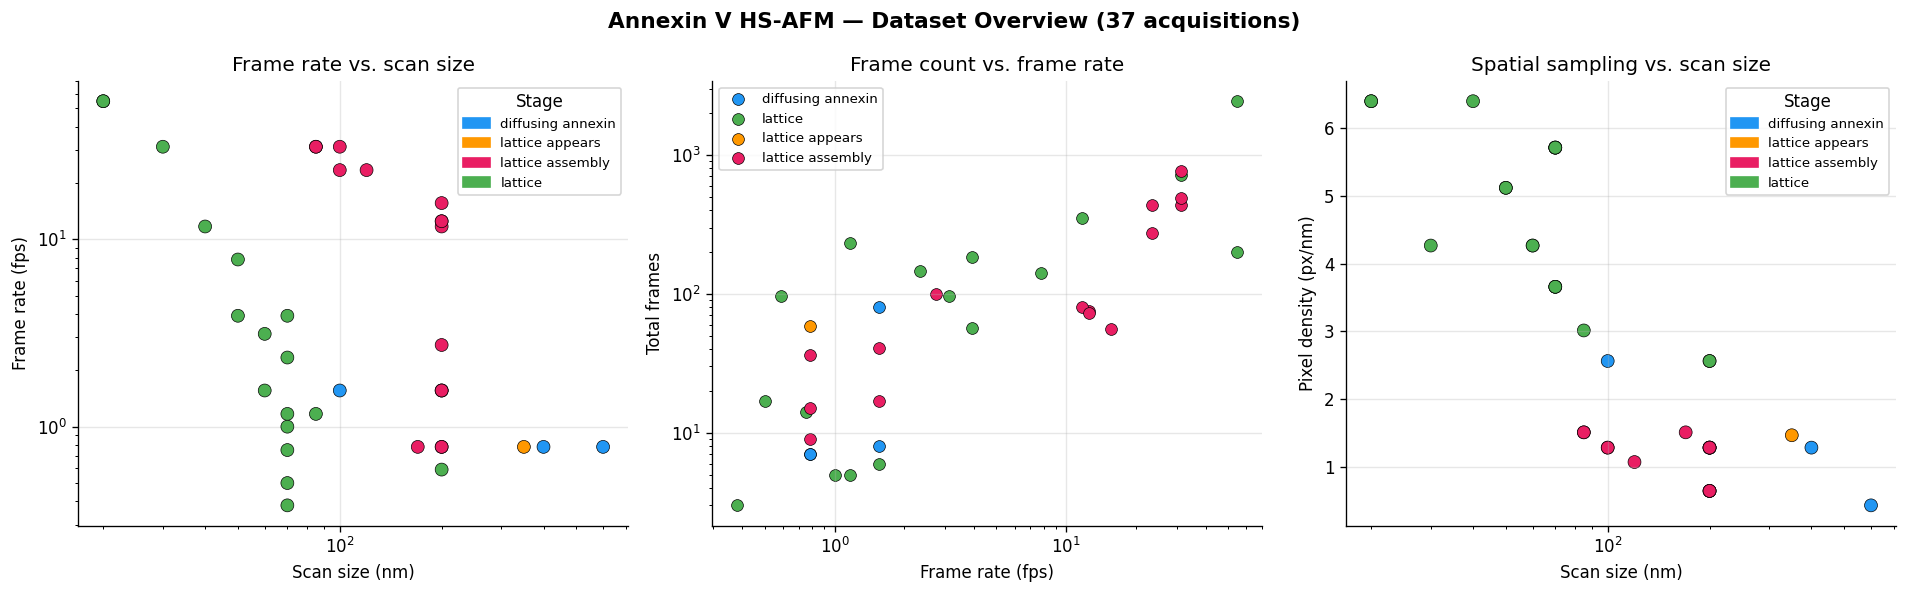

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Annexin V HS-AFM — Dataset Overview (37 acquisitions)', fontsize=13, fontweight='bold')

colors = [CAT_COLORS[n] for n in df['note']]
patches = [mpatches.Patch(color=c, label=k) for k, c in CAT_COLORS.items()]

ax = axes[0]
ax.scatter(df['scan_nm'], df['fps'], c=colors, s=60, edgecolors='k', lw=0.4, zorder=3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Scan size (nm)'); ax.set_ylabel('Frame rate (fps)')
ax.set_title('Frame rate vs. scan size')
ax.legend(handles=patches, fontsize=8, title='Stage'); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for cat, grp in df.groupby('note'):
    ax2.scatter(grp['fps'], grp['frames'], label=cat, color=CAT_COLORS[cat], s=50, edgecolors='k', lw=0.4)
ax2.set_xlabel('Frame rate (fps)'); ax2.set_ylabel('Total frames')
ax2.set_title('Frame count vs. frame rate')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.grid(True, alpha=0.3); ax2.legend(fontsize=8)

ax3 = axes[2]
px_per_nm = df['xpx'] / df['scan_nm']
ax3.scatter(df['scan_nm'], px_per_nm, c=colors, s=60, edgecolors='k', lw=0.4)
ax3.set_xlabel('Scan size (nm)'); ax3.set_ylabel('Pixel density (px/nm)')
ax3.set_title('Spatial sampling vs. scan size')
ax3.set_xscale('log'); ax3.grid(True, alpha=0.3)
ax3.legend(handles=patches, fontsize=8, title='Stage')

plt.tight_layout(); plt.show()

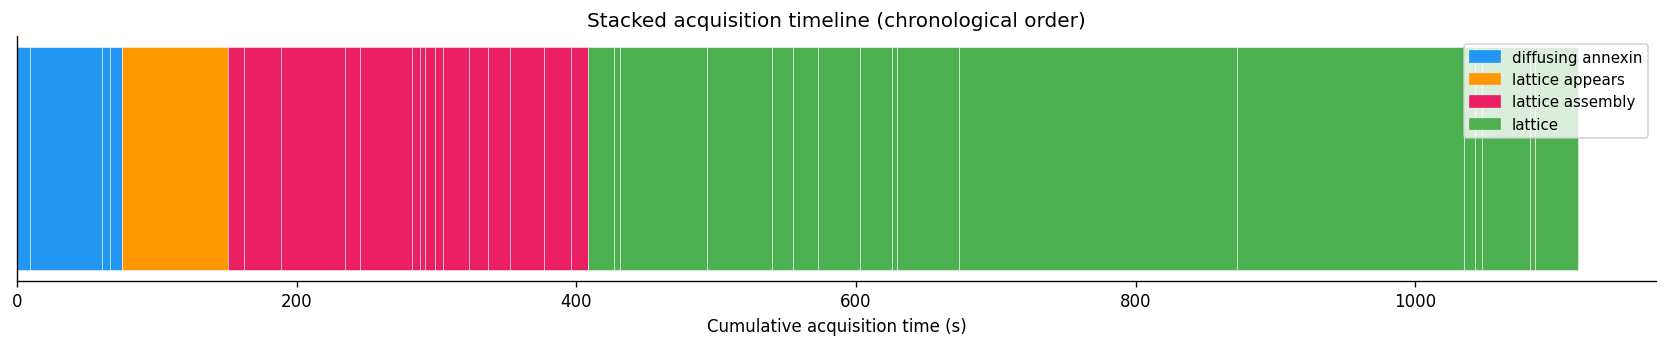

Total acquisition time: 1116 s  (18.6 min)


In [5]:
# Acquisition timeline stacked bar
fig, ax = plt.subplots(figsize=(14, 3))
df_s = df.sort_values('stack').reset_index(drop=True)
df_s['duration_s'] = df_s['frames'] / df_s['fps']
cumulative = 0
for _, row in df_s.iterrows():
    ax.barh(0, row['duration_s'], left=cumulative, color=CAT_COLORS[row['note']],
            edgecolor='white', linewidth=0.3, height=0.6)
    cumulative += row['duration_s']
ax.set_xlabel('Cumulative acquisition time (s)')
ax.set_yticks([])
ax.set_title('Stacked acquisition timeline (chronological order)')
ax.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Total acquisition time: {df_s["duration_s"].sum():.0f} s  '
      f'({df_s["duration_s"].sum()/60:.1f} min)')

## 3 · Download & extract the dataset

The full archive is ~1.6 GB. This cell resumes partial downloads.  
**Skip this cell** and just update `DATA_DIR` below if you already have the data.

In [6]:
import zipfile
from tqdm.notebook import tqdm

DATA_DIR = Path('../data/raw/AnnexinV_HSAFM')
ZIP_PATH = DATA_DIR / 'Annexin_V_HS_AFM.zip'

# Skip download — data already present locally
# Extract only if the stack folders are not yet present
stack_dirs = [d for d in (DATA_DIR / 'For Zenodo').iterdir() if d.is_dir()] \
    if (DATA_DIR / 'For Zenodo').exists() else []

if not stack_dirs:
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        for member in tqdm(z.namelist(), desc='Extracting'):
            if not (DATA_DIR / member).exists():
                z.extract(member, DATA_DIR)
    print('Done.')
else:
    print(f'Data already extracted ({len(stack_dirs)} stacks found).')

Data already extracted (37 stacks found).


## 4 · Load a stack with playnano

Set `STACK_NAME` to any key in `STACK_META`. Suggestions below cover all four stages.

In [7]:
from playnano.afm_stack import AFMImageStack

# ---- Choose a stack ----
STACK_NAME = 'imaging-13.49.42.515'   # lattice assembly, 100 frames, 200 nm, 2.73 fps
# Other good choices:
#   'imaging-13.26.46.569'  diffusing annexin  81 frames  100 nm
#   'imaging-13.46.35.510'  lattice appears    59 frames  350 nm
#   'imaging-14.14.31.069'  formed lattice    145 frames   70 nm
#   'imaging-14.23.44.983'  formed lattice   2437 frames   20 nm  54.69 fps
# -------------------------

DATA_DIR = Path('../data/raw/AnnexinV_HSAFM/For Zenodo')
CHANNEL  = 'height_retrace'  # channel name used in this dataset's .jpk files

matches = sorted(DATA_DIR.rglob(STACK_NAME))
assert matches, f'Stack folder not found: {STACK_NAME}'

stack    = AFMImageStack.load_data(str(matches[0]), channel=CHANNEL)
frames   = stack.data * 1e9           # metres -> nanometres
px_to_nm = stack.pixel_size_nm
meta     = STACK_META[STACK_NAME]
fps, scan_nm = meta['fps'], meta['scan_nm']
T, H, W  = frames.shape

print(f'Stack   : {STACK_NAME}')
print(f'Shape   : {T} frames x {H} x {W} px')
print(f'Scan    : {scan_nm} nm  ({px_to_nm:.3f} nm/px)')
print(f'FPS     : {fps}  ({T/fps:.1f} s total)')
print(f'Stage   : {meta["note"]}')
print(f'Height  : {frames.min():.2f} to {frames.max():.2f} nm')

12:27:58 | INFO |jpk.py:jpk:load_jpk:213 | Loading image from : C:\Users\Administrator\Documents\GitHub\RMS AFM & SPM Meeting 2026\data\raw\AnnexinV_HSAFM\For Zenodo\imaging-13.49.42.515\save-2022.11.04-13.49.42.544.jpk
12:27:58 | INFO |jpk.py:jpk:_load_jpk_tags:274 | Configuration loaded from : c:\Users\Administrator\.conda\envs\RMS2026_env\Lib\site-packages\AFMReader\default_config.yaml
12:27:58 | INFO |jpk.py:jpk:load_jpk:251 | [save-2022.11.04-13.49.42.544] : Extracted image.
12:27:58 | INFO |jpk.py:jpk:load_jpk:213 | Loading image from : C:\Users\Administrator\Documents\GitHub\RMS AFM & SPM Meeting 2026\data\raw\AnnexinV_HSAFM\For Zenodo\imaging-13.49.42.515\save-2022.11.04-13.49.42.544.jpk
12:27:58 | INFO |jpk.py:jpk:_load_jpk_tags:274 | Configuration loaded from : c:\Users\Administrator\.conda\envs\RMS2026_env\Lib\site-packages\AFMReader\default_config.yaml
12:27:58 | INFO |jpk.py:jpk:load_jpk:251 | [save-2022.11.04-13.49.42.544] : Extracted image.
12:27:58 | INFO |jpk.py:jpk:lo

Stack   : imaging-13.49.42.515
Shape   : 101 frames x 256 x 256 px
Scan    : 200 nm  (0.781 nm/px)
FPS     : 2.73  (37.0 s total)
Stage   : lattice assembly
Height  : 520510466463.71 to 536345011808.65 nm


## 5 · Stack overview: selected frames + statistics

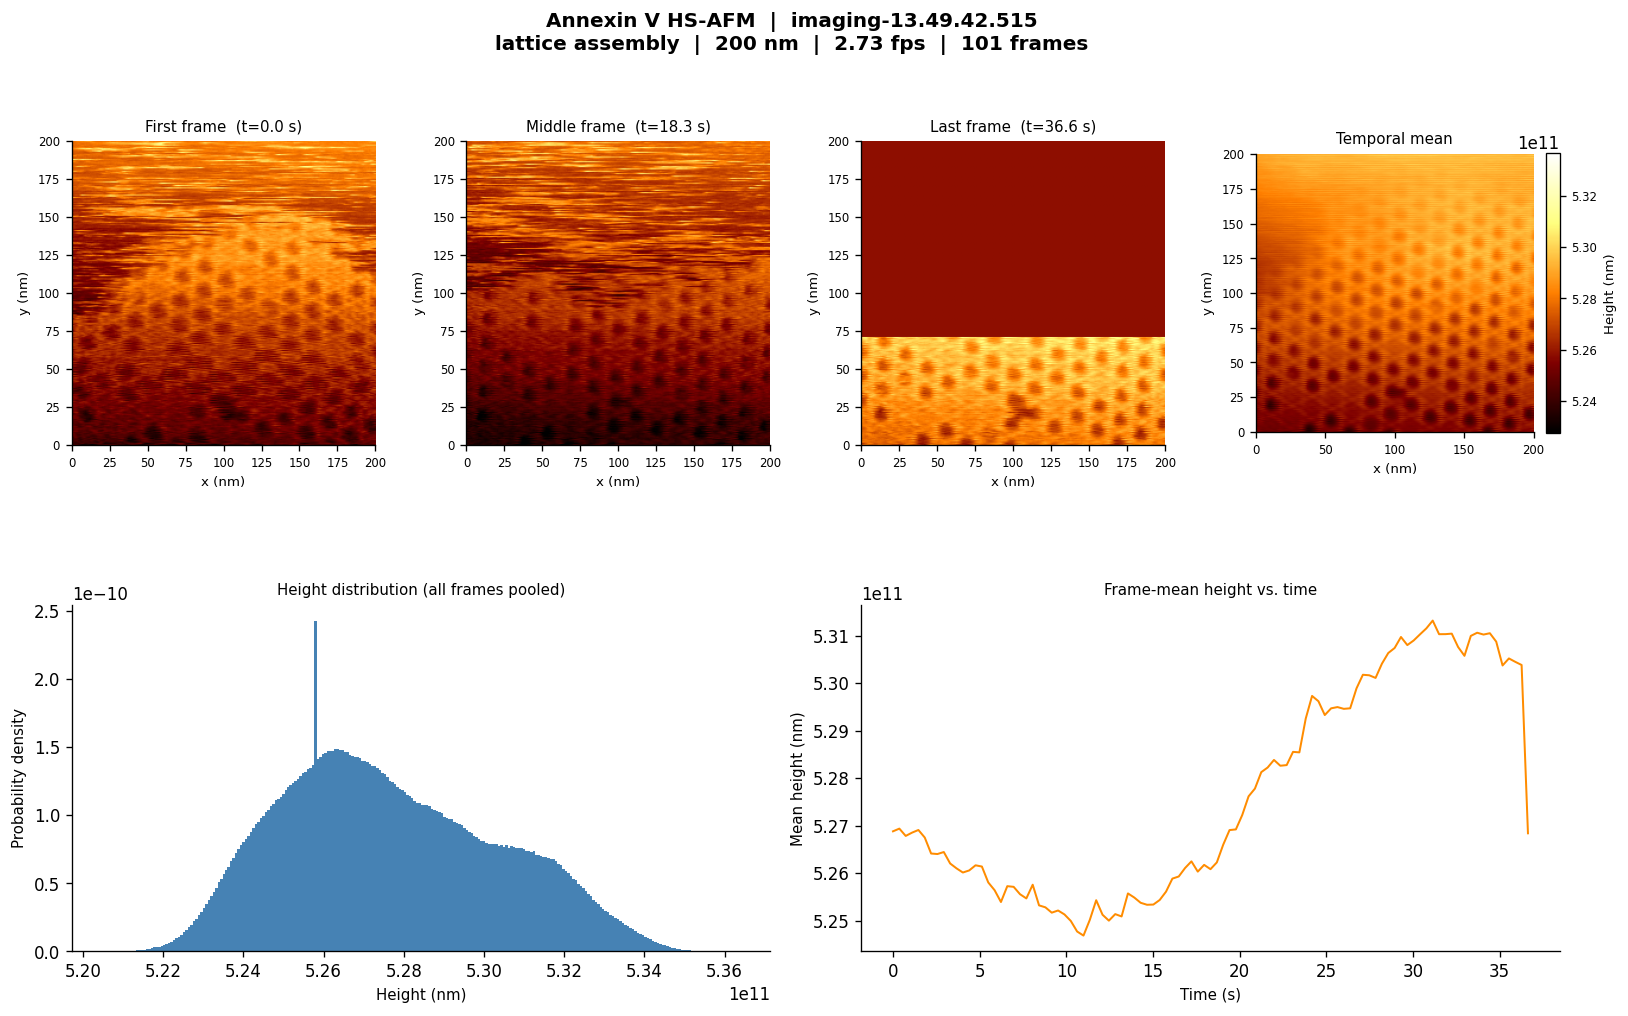

In [8]:
vmin, vmax = np.percentile(frames, 1), np.percentile(frames, 99)
extent  = [0, W * px_to_nm, 0, H * px_to_nm]
mean_img = frames.mean(axis=0)
idx    = [0, T // 2, T - 1]
labels = ['First frame', 'Middle frame', 'Last frame']

fig = plt.figure(figsize=(16, 9))
fig.suptitle(
    f'Annexin V HS-AFM  |  {STACK_NAME}\n'
    f'{meta["note"]}  |  {scan_nm} nm  |  {fps} fps  |  {T} frames',
    fontsize=12, fontweight='bold')
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.3)

def afm_imshow(ax, data, title):
    im = ax.imshow(data, cmap='afmhot', vmin=vmin, vmax=vmax,
                   origin='lower', extent=extent, aspect='equal')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x (nm)', fontsize=8); ax.set_ylabel('y (nm)', fontsize=8)
    ax.tick_params(labelsize=7); return im

for col, (fi, lbl) in enumerate(zip(idx, labels)):
    ax = fig.add_subplot(gs[0, col])
    afm_imshow(ax, frames[fi], f'{lbl}  (t={fi/fps:.1f} s)')
ax_mean = fig.add_subplot(gs[0, 3])
im = afm_imshow(ax_mean, mean_img, 'Temporal mean')
cb = fig.colorbar(im, ax=ax_mean, fraction=0.046, pad=0.04)
cb.set_label('Height (nm)', fontsize=8); cb.ax.tick_params(labelsize=7)

ax_h = fig.add_subplot(gs[1, :2])
ax_h.hist(frames.ravel(), bins=256, color='steelblue', edgecolor='none', density=True)
ax_h.set_xlabel('Height (nm)', fontsize=9); ax_h.set_ylabel('Probability density', fontsize=9)
ax_h.set_title('Height distribution (all frames pooled)', fontsize=9)

ax_t = fig.add_subplot(gs[1, 2:])
times = np.arange(T) / fps
ax_t.plot(times, frames.mean(axis=(1,2)), color='darkorange', lw=1.2)
ax_t.set_xlabel('Time (s)', fontsize=9); ax_t.set_ylabel('Mean height (nm)', fontsize=9)
ax_t.set_title('Frame-mean height vs. time', fontsize=9)

plt.show()

## 6 · Height line profiles

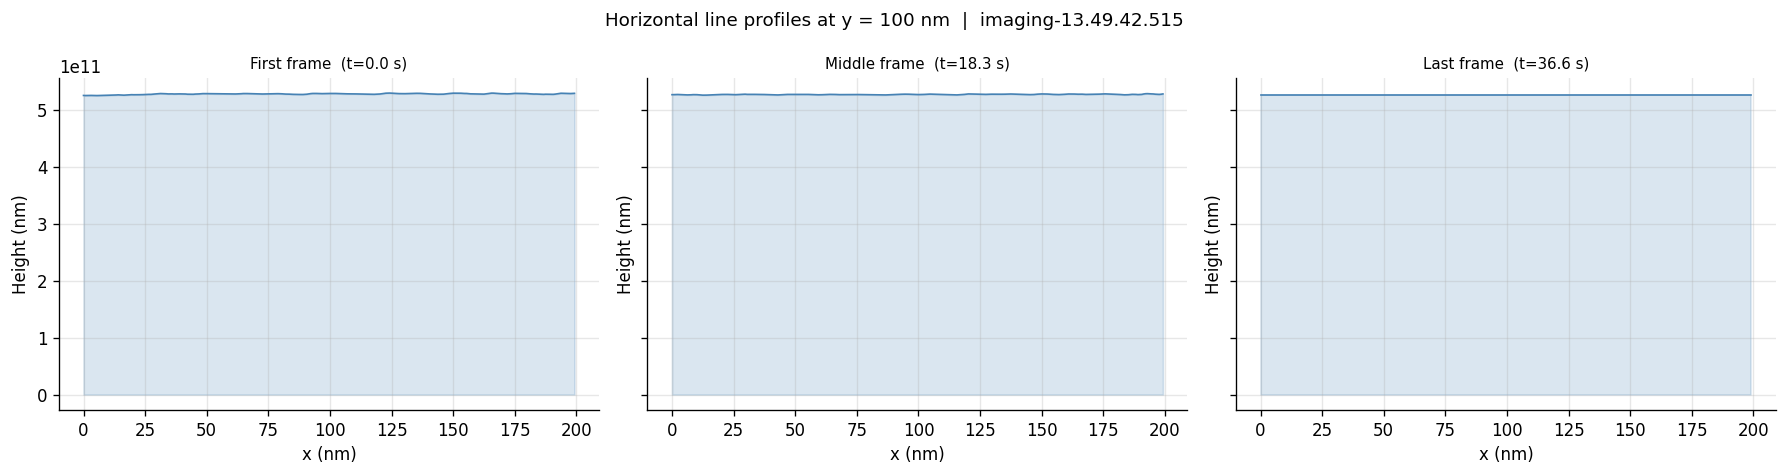

In [9]:
mid_row = H // 2
x_nm = np.arange(W) * px_to_nm

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(f'Horizontal line profiles at y = {mid_row * px_to_nm:.0f} nm  |  {STACK_NAME}', fontsize=11)

for ax, fi, lbl in zip(axes, idx, labels):
    ax.plot(x_nm, frames[fi, mid_row, :], lw=1, color='steelblue')
    ax.fill_between(x_nm, frames[fi, mid_row, :], alpha=0.2, color='steelblue')
    ax.set_title(f'{lbl}  (t={fi/fps:.1f} s)', fontsize=9)
    ax.set_xlabel('x (nm)'); ax.set_ylabel('Height (nm)')
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 7 · Temporal standard deviation (dynamics map)

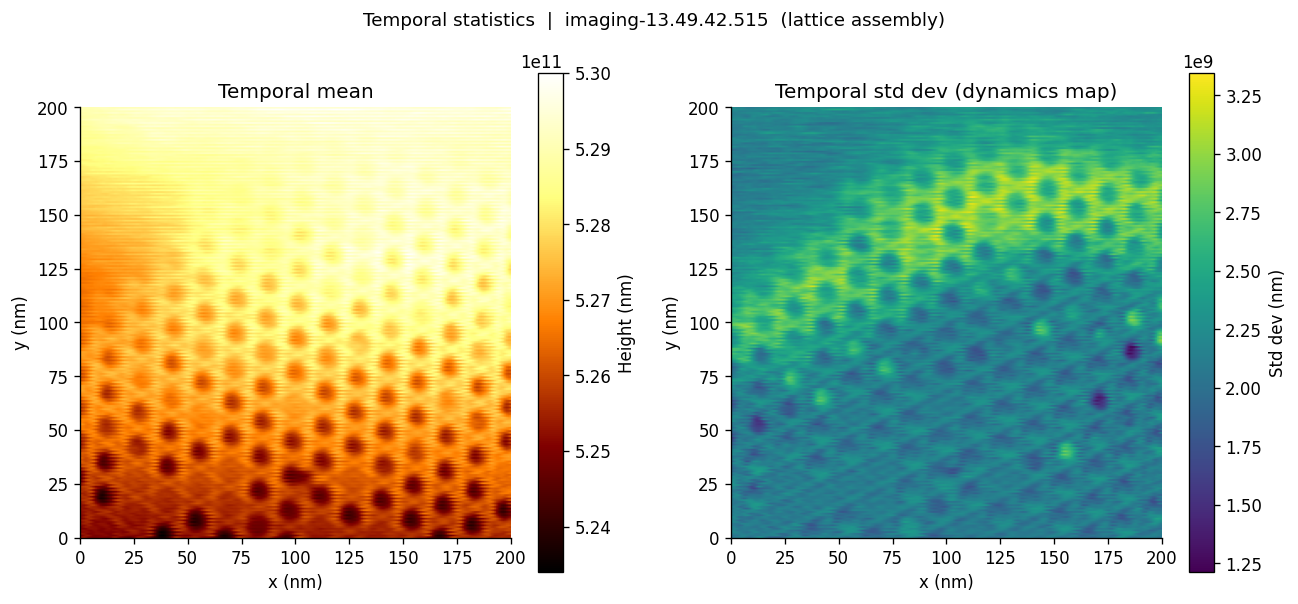

Max pixel std : 3347385278.287 nm
Median pixel std: 2224912457.149 nm


In [10]:
std_map = frames.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle(f'Temporal statistics  |  {STACK_NAME}  ({meta["note"]})', fontsize=11)

im0 = axes[0].imshow(mean_img, cmap='afmhot', origin='lower', extent=extent, aspect='equal')
axes[0].set_title('Temporal mean'); axes[0].set_xlabel('x (nm)'); axes[0].set_ylabel('y (nm)')
fig.colorbar(im0, ax=axes[0], label='Height (nm)')

im1 = axes[1].imshow(std_map, cmap='viridis', origin='lower', extent=extent, aspect='equal')
axes[1].set_title('Temporal std dev (dynamics map)')
axes[1].set_xlabel('x (nm)'); axes[1].set_ylabel('y (nm)')
fig.colorbar(im1, ax=axes[1], label='Std dev (nm)')

plt.tight_layout(); plt.show()
print(f'Max pixel std : {std_map.max():.3f} nm')
print(f'Median pixel std: {np.median(std_map):.3f} nm')

## 8 · Inline animation

Interactive playback rendered with `to_jshtml()`. For large stacks `MAX_FRAMES` subsamples to keep it snappy.

In [ ]:
MAX_FRAMES = min(T, 100)
step = max(1, T // MAX_FRAMES)
sub_frames = frames[::step]
n = len(sub_frames)

fig_a, ax_a = plt.subplots(figsize=(5, 5))
ax_a.axis('off')
im_a = ax_a.imshow(sub_frames[0], cmap='afmhot', vmin=vmin, vmax=vmax,
                    origin='lower', extent=extent, aspect='equal')
ttl = ax_a.set_title('', fontsize=9)
fig_a.colorbar(im_a, ax=ax_a, fraction=0.046, pad=0.04, label='Height (nm)')
plt.tight_layout()

def _upd(i):
    im_a.set_data(sub_frames[i])
    ttl.set_text(f'{STACK_NAME}  |  frame {i*step}/{T-1}  (t={i*step/fps:.2f} s)')
    return im_a, ttl

anim = FuncAnimation(fig_a, _upd, frames=n,
                     interval=max(50, int(1000/(fps/step))), blit=True)
plt.close(fig_a)
display(HTML(anim.to_jshtml()))

Animation size has reached 21304351 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


## 9 · Kymograph (space–time slice)

In [ ]:
kymo = frames[:, H // 2, :]   # shape (T, W)
t_ax = np.arange(T) / fps

fig, ax = plt.subplots(figsize=(12, 4))
im_k = ax.imshow(kymo.T, cmap='afmhot', vmin=vmin, vmax=vmax,
                  origin='lower',
                  extent=[t_ax[0], t_ax[-1], 0, W * px_to_nm],
                  aspect='auto')
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('x position (nm)', fontsize=10)
ax.set_title(f'Kymograph  |  {STACK_NAME}  ({meta["note"]})', fontsize=10)
fig.colorbar(im_k, ax=ax, label='Height (nm)')
plt.tight_layout(); plt.show()

## 10 · Cross-stage comparison

Load one stack per biological stage and compare mean height images.

In [ ]:
STAGE_STACKS = {
    'diffusing annexin': 'imaging-13.26.46.569',
    'lattice appears':   'imaging-13.46.35.510',
    'lattice assembly':  'imaging-13.49.42.515',
    'lattice':           'imaging-14.14.31.069',
}

loaded = {}
for stage, sname in STAGE_STACKS.items():
    m = sorted(DATA_DIR.rglob(sname))
    if not m:
        print(f'  [SKIP] {sname} not found'); continue
    print(f'Loading {sname} ...')
    s = AFMImageStack.load_data(str(m[0]), channel=CHANNEL)
    f_nm = s.data * 1e9
    loaded[stage] = (f_nm.mean(axis=0), s.pixel_size_nm, STACK_META[sname])
print(f'Loaded {len(loaded)} stacks.')

In [ ]:
fig, axes = plt.subplots(1, len(loaded), figsize=(4.5 * len(loaded), 5))
fig.suptitle('Mean height images — one per biological stage', fontsize=12, fontweight='bold')

for ax, (stage, (mimg, p2n, m)) in zip(axes, loaded.items()):
    ny, nx = mimg.shape
    ext = [0, nx * p2n, 0, ny * p2n]
    vm0, vm1 = np.percentile(mimg, 1), np.percentile(mimg, 99)
    im = ax.imshow(mimg, cmap='afmhot', vmin=vm0, vmax=vm1,
                   origin='lower', extent=ext, aspect='equal')
    ax.set_title(f"{stage}\n{m['scan_nm']} nm  |  {m['fps']} fps", fontsize=9)
    ax.set_xlabel('x (nm)', fontsize=8); ax.set_ylabel('y (nm)', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Height (nm)')

plt.tight_layout(); plt.show()

## 11 · Export as OME-TIFF and NPZ

In [ ]:
import tifffile

out_dir = Path('./annexin_exports')
out_dir.mkdir(exist_ok=True)

tif_path = out_dir / f'{STACK_NAME}.ome.tif'
tifffile.imwrite(
    tif_path, frames.astype('float32'), imagej=True,
    metadata={'axes': 'TYX', 'unit': 'nm', 'fps': fps, 'scan_nm': scan_nm}
)
print(f'TIFF -> {tif_path}  ({tif_path.stat().st_size/1e6:.1f} MB)')

npz_path = out_dir / f'{STACK_NAME}.npz'
np.savez_compressed(npz_path, frames=frames.astype('float32'),
                    px_to_nm=px_to_nm, fps=fps, scan_nm=scan_nm)
print(f'NPZ  -> {npz_path}  ({npz_path.stat().st_size/1e6:.1f} MB)')

## 12 · ML analysis: dimensionality reduction, denoising & clustering

Three complementary views:
1. **PCA** — frame-level trajectory through morphology space  
2. **UMAP** — non-linear embedding to reveal assembly dynamics  
3. **SVD denoising** — reconstruct frames from top-k components  
4. **Spatial K-means** — segment bilayer, protein and lattice regions

In [ ]:
# ── Preprocessing for ML ──────────────────────────────────────────────────────
# 1. Crop to bottom quarter (rows 0 : H//4, i.e. the bottom in the displayed image)
# 2. Plane-flatten each frame: fit ax + by + c and subtract so tilt doesn't
#    dominate the variance captured by PCA/UMAP

def plane_flatten(f):
    """Subtract a least-squares 2D plane from a single frame."""
    ry, rx = np.mgrid[0:f.shape[0], 0:f.shape[1]].astype(np.float64)
    A = np.stack([ry.ravel(), rx.ravel(), np.ones(f.size)], axis=1)
    coeff, *_ = np.linalg.lstsq(A, f.ravel(), rcond=None)
    return f - (A @ coeff).reshape(f.shape)

H_ml = H // 4                                         # bottom quarter row count
frames_ml = np.stack([plane_flatten(frames[i, :H_ml, :]) for i in range(T)])

# Quick sanity plot
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fig.suptitle(f'ML preprocessing  |  frame {T//2}', fontsize=10)
vm = np.percentile(frames_ml, [1, 99])
for ax, fi, lbl in zip(axes, [0, T//2, T-1], ['First', 'Middle', 'Last']):
    ax.imshow(frames_ml[fi], cmap='afmhot', vmin=vm[0], vmax=vm[1],
              origin='lower', aspect='equal',
              extent=[0, frames_ml.shape[2]*px_to_nm, 0, H_ml*px_to_nm])
    ax.set_title(f'{lbl} frame (plane-flattened, bottom ¼)')
    ax.set_xlabel('x (nm)'); ax.set_ylabel('y (nm)')
plt.tight_layout(); plt.show()
print(f'frames_ml shape: {frames_ml.shape}  ({H_ml} × {frames_ml.shape[2]} px)')

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Frame matrix from plane-flattened bottom quarter ──────────────────────────
X = frames_ml.reshape(T, -1)                   # (T, H_ml*W)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

n_comp = min(T, 50)
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_sc)               # (T, n_comp)
t_axis = np.arange(T) / fps                   # seconds

# ── Plot 1: explained variance ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'PCA of frame stack  |  {STACK_NAME}  (bottom ¼, plane-flattened)',
             fontsize=11, fontweight='bold')

ev = pca.explained_variance_ratio_
axes[0].bar(np.arange(1, 11), ev[:10] * 100, color='steelblue', edgecolor='k', lw=0.4)
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree plot (top 10 PCs)')
axes[0].text(0.6, 0.85, f'PC1+PC2 = {(ev[0]+ev[1])*100:.1f}%',
             transform=axes[0].transAxes, fontsize=9)

# ── Plot 2: PC1 & PC2 time series ─────────────────────────────────────────────
axes[1].plot(t_axis, X_pca[:, 0], label='PC1', color='#E91E63', lw=1.2)
axes[1].plot(t_axis, X_pca[:, 1], label='PC2', color='#2196F3', lw=1.2)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Score')
axes[1].set_title('PC scores vs. time'); axes[1].legend(); axes[1].grid(alpha=0.3)

# ── Plot 3: PC1 vs PC2 phase portrait coloured by time ───────────────────────
sc = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=t_axis,
                     cmap='plasma', s=20, edgecolors='none', zorder=3)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].set_title('Phase portrait (colour = time)')
cb = fig.colorbar(sc, ax=axes[2], pad=0.02); cb.set_label('Time (s)', fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Cumulative variance in 5 PCs: {ev[:5].sum()*100:.1f}%')

In [ ]:
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=min(15, T - 1),
                    min_dist=0.1, random_state=42, verbose=False)
X_umap = reducer.fit_transform(X_pca)         # (T, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'UMAP embedding  |  {STACK_NAME}  (bottom ¼, plane-flattened)',
             fontsize=11, fontweight='bold')

sc0 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=t_axis,
                      cmap='plasma', s=25, edgecolors='none')
cb0 = fig.colorbar(sc0, ax=axes[0]); cb0.set_label('Time (s)', fontsize=8)
axes[0].set_title('Colour = time'); axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

frame_means = frames_ml.mean(axis=(1, 2))
sc1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=frame_means,
                      cmap='viridis', s=25, edgecolors='none')
cb1 = fig.colorbar(sc1, ax=axes[1]); cb1.set_label('Mean height (nm)', fontsize=8)
axes[1].set_title('Colour = mean height'); axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

step = max(1, T // 20)
for i in range(0, T - step, step):
    axes[0].annotate('', xy=X_umap[i + step], xytext=X_umap[i],
                     arrowprops=dict(arrowstyle='->', color='white', lw=0.8))

plt.tight_layout(); plt.show()

In [ ]:
U, S, Vt = np.linalg.svd(X_sc, full_matrices=False)

ranks = [1, 3, 10, 30]
show_frame = T // 2
W_ml = frames_ml.shape[2]

fig, axes = plt.subplots(2, len(ranks) + 1, figsize=(16, 6))
fig.suptitle(f'SVD denoising  |  frame {show_frame}  |  {STACK_NAME}  (bottom ¼, plane-flattened)',
             fontsize=11, fontweight='bold')

orig = frames_ml[show_frame]
vm0, vm1 = np.percentile(orig, 1), np.percentile(orig, 99)
ext_ml = [0, W_ml * px_to_nm, 0, H_ml * px_to_nm]

axes[0, 0].imshow(orig, cmap='afmhot', vmin=vm0, vmax=vm1, origin='lower',
                  extent=ext_ml, aspect='equal')
axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
axes[1, 0].axis('off')

snrs = []
for col, k in enumerate(ranks, start=1):
    recon_sc = (U[:, :k] * S[:k]) @ Vt[:k, :]
    recon = scaler.inverse_transform(recon_sc)
    frame_r = recon[show_frame].reshape(H_ml, W_ml)

    axes[0, col].imshow(frame_r, cmap='afmhot', vmin=vm0, vmax=vm1, origin='lower',
                        extent=ext_ml, aspect='equal')
    axes[0, col].set_title(f'k = {k}  ({S[:k].sum()/S.sum()*100:.1f}% energy)')
    axes[0, col].axis('off')

    residual = orig - frame_r
    axes[1, col].imshow(residual, cmap='bwr',
                        vmin=-np.abs(residual).max(), vmax=np.abs(residual).max(),
                        origin='lower', extent=ext_ml, aspect='equal')
    axes[1, col].set_title(f'Residual  RMSE={np.sqrt((residual**2).mean()):.3f} nm')
    axes[1, col].axis('off')
    snrs.append(10 * np.log10(orig.var() / residual.var()))

plt.tight_layout(); plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 3))
ax2.plot(ranks, snrs, 'o-', color='steelblue')
ax2.set_xlabel('SVD rank k'); ax2.set_ylabel('SNR (dB)')
ax2.set_title('Denoising SNR vs. rank'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift as nd_shift

# Register every frame to the first frame using phase cross-correlation.
# upsample_factor=10 gives sub-pixel accuracy (0.1 px resolution).
ref = frames_ml[0]
shifts = []
for i in range(T):
    s, _, _ = phase_cross_correlation(ref, frames_ml[i], upsample_factor=10)
    shifts.append(s)

shifts = np.array(shifts)          # (T, 2)  — [row_shift, col_shift]
frames_reg = np.stack([nd_shift(frames_ml[i], shifts[i]) for i in range(T)])

# ── Diagnostic: shift magnitude over time ─────────────────────────────────────
shift_mag = np.linalg.norm(shifts, axis=1) * px_to_nm   # nm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Drift correction  |  {STACK_NAME}', fontsize=11, fontweight='bold')

axes[0].plot(t_axis, shifts[:, 1] * px_to_nm, label='x (col)', color='steelblue', lw=1.2)
axes[0].plot(t_axis, shifts[:, 0] * px_to_nm, label='y (row)', color='tomato',    lw=1.2)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Shift (nm)')
axes[0].set_title('Per-frame shift vs. time'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_axis, shift_mag, color='purple', lw=1.2)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Shift magnitude (nm)')
axes[1].set_title('Total drift magnitude'); axes[1].grid(alpha=0.3)
axes[1].axhline(px_to_nm, color='k', ls='--', lw=0.8, label='1 px')
axes[1].legend(fontsize=8)

vm = np.percentile(frames_reg, [1, 99])
axes[2].imshow(frames_reg.mean(axis=0), cmap='afmhot', vmin=vm[0], vmax=vm[1],
               origin='lower', aspect='equal',
               extent=[0, W_ml*px_to_nm, 0, H_ml*px_to_nm])
axes[2].set_title('Temporal mean (registered)')
axes[2].set_xlabel('x (nm)'); axes[2].set_ylabel('y (nm)')

plt.tight_layout(); plt.show()
print(f'Max drift: {shift_mag.max():.1f} nm  ({shift_mag.max()/px_to_nm:.1f} px)')

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from skimage.filters import gaussian, median
from skimage.morphology import disk

# ── Build feature map on the registered stack ─────────────────────────────────
mean_reg = frames_reg.mean(axis=0)
std_reg  = frames_reg.std(axis=0)   # true dynamics — drift no longer inflates this

# Spatial texture features computed on the temporal mean
# (robust to residual drift; captures ordered lattice vs diffuse protein)
smooth_fine  = gaussian(mean_reg, sigma=1)
smooth_coarse = gaussian(mean_reg, sigma=4)
# Band-pass: fine structure = what's sharper than the coarse background
fine_structure = smooth_fine - smooth_coarse

# Local spatial roughness: std in a 3-px disk neighbourhood of the mean image
local_rough = np.sqrt(np.maximum(
    gaussian(mean_reg**2, sigma=2) - gaussian(mean_reg, sigma=2)**2, 0
))

# Spike-artefact suppression: median-filter the std map so single-pixel
# scan-line glitches don't get their own cluster
std_clean = median(std_reg, footprint=disk(2))

feat_map = np.stack([
    mean_reg,        # absolute height level
    std_clean,       # temporal dynamics (registered, artefact-suppressed)
    fine_structure,  # local sharpness — picks out lattice vs background
    local_rough,     # spatial roughness — ordered lattice is smoother
], axis=-1)                                          # (H_ml, W_ml, 4)

feat_flat = feat_map.reshape(-1, 4)
feat_sc   = StandardScaler().fit_transform(feat_flat)

# ── Clustering ───────────────────────────────────────────────────────���────────
N_CLUSTERS   = 4
cluster_names = ['Background', 'Low protein', 'Assembling', 'Lattice']

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels_km = km.fit_predict(feat_sc).reshape(H_ml, W_ml)

gm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                     random_state=42, n_init=5)
labels_gm = gm.fit_predict(feat_sc).reshape(H_ml, W_ml)

def sort_by_mean_height(labels, mean_img):
    heights = [mean_img[labels == i].mean() for i in range(N_CLUSTERS)]
    order   = np.argsort(heights)
    remap   = {old: new for new, old in enumerate(order)}
    return np.vectorize(remap.get)(labels)

labels_km = sort_by_mean_height(labels_km, mean_reg)
labels_gm = sort_by_mean_height(labels_gm, mean_reg)

# ── Feature maps diagnostic ───────────────────────────────────────────────────
feat_names = ['Mean height (nm)', 'Temporal std (nm, cleaned)',
              'Fine structure', 'Local roughness']
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
fig.suptitle('Clustering features (registered stack)', fontsize=10, fontweight='bold')
for ax, feat, name in zip(axes, feat_map.T, feat_names):
    im = ax.imshow(feat.T, cmap='viridis', origin='lower', aspect='equal',
                   extent=[0, W_ml*px_to_nm, 0, H_ml*px_to_nm])
    ax.set_title(name, fontsize=9); ax.set_xlabel('x (nm)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0].set_ylabel('y (nm)')
plt.tight_layout(); plt.show()

# ── Segmentation results ───────────────────────────���──────────────────────────
cmap_seg = plt.cm.get_cmap('tab10', N_CLUSTERS)
ext_ml   = [0, W_ml*px_to_nm, 0, H_ml*px_to_nm]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f'Improved spatial clustering  |  {STACK_NAME}  (drift-corrected)',
             fontsize=11, fontweight='bold')

vm = np.percentile(mean_reg, [1, 99])
axes[0].imshow(mean_reg, cmap='afmhot', vmin=vm[0], vmax=vm[1],
               origin='lower', extent=ext_ml, aspect='equal')
axes[0].set_title('Temporal mean (registered)'); axes[0].set_xlabel('x (nm)'); axes[0].set_ylabel('y (nm)')

axes[1].imshow(std_clean, cmap='viridis', origin='lower', extent=ext_ml, aspect='equal')
axes[1].set_title('Temporal std (cleaned)'); axes[1].set_xlabel('x (nm)')

for ax, labels, title in zip(axes[2:], [labels_km, labels_gm],
                              [f'K-means (k={N_CLUSTERS})', f'GMM (k={N_CLUSTERS})']):
    im = ax.imshow(labels, cmap=cmap_seg, vmin=-0.5, vmax=N_CLUSTERS - 0.5,
                   origin='lower', extent=ext_ml, aspect='equal')
    ax.set_title(title); ax.set_xlabel('x (nm)')
    cb = fig.colorbar(im, ax=ax, ticks=range(N_CLUSTERS))
    cb.ax.set_yticklabels(cluster_names, fontsize=7)

plt.tight_layout(); plt.show()

print('K-means cluster fractions:')
for i, name in enumerate(cluster_names):
    frac = (labels_km == i).sum() / (H_ml * W_ml)
    print(f'  {name:20s}: {frac*100:.1f}%')

## 13 · Spatial dynamics explorer

Where is the system exploring the most, and how does that change over time?

1. **PCA spatial modes** — which pixels drive the dominant variance axes  
2. **Pixel-level dynamics maps** — trajectory length, frame-difference, lag-1 autocorrelation  
3. **Time-windowed std** — how the "hotspots" migrate as assembly progresses  
4. **Dynamic vs. static region comparison** — height distributions and temporal traces

In [ ]:
# ── PCA spatial modes ─────────────────────────────────────────────────────────
# pca.components_ shape: (n_comp, H_ml*W_ml)
# Each row is a spatial eigenvector — positive = pixels that increase together
# along that PC, negative = pixels that decrease.

n_modes = 4
mode_maps = pca.components_[:n_modes].reshape(n_modes, H_ml, W_ml)

fig, axes = plt.subplots(2, n_modes, figsize=(18, 7))
fig.suptitle(f'PCA spatial modes  |  {STACK_NAME}  (bottom ¼, plane-flattened)',
             fontsize=11, fontweight='bold')

vm_mean = np.percentile(mean_reg, [1, 99])
ext_ml  = [0, W_ml*px_to_nm, 0, H_ml*px_to_nm]

for k in range(n_modes):
    mode = mode_maps[k]
    vabs = np.abs(mode).max()

    # Top row: loading map
    im = axes[0, k].imshow(mode, cmap='RdBu_r', vmin=-vabs, vmax=vabs,
                            origin='lower', extent=ext_ml, aspect='equal')
    axes[0, k].set_title(f'PC{k+1}  ({pca.explained_variance_ratio_[k]*100:.1f}% var)',
                          fontsize=9)
    axes[0, k].set_xlabel('x (nm)')
    if k == 0: axes[0, k].set_ylabel('Loading (a.u.)')
    fig.colorbar(im, ax=axes[0, k], fraction=0.046, pad=0.04)

    # Bottom row: loading magnitude overlaid as contour on mean image
    axes[1, k].imshow(mean_reg, cmap='afmhot', vmin=vm_mean[0], vmax=vm_mean[1],
                       origin='lower', extent=ext_ml, aspect='equal')
    axes[1, k].contour(np.abs(mode),
                        levels=np.percentile(np.abs(mode), [70, 85, 95]),
                        colors=['cyan', 'lime', 'white'], linewidths=0.6,
                        origin='upper',
                        extent=ext_ml)
    axes[1, k].set_title(f'|PC{k+1}| contours on mean', fontsize=9)
    axes[1, k].set_xlabel('x (nm)')
    if k == 0: axes[1, k].set_ylabel('y (nm)')

plt.tight_layout(); plt.show()
print('Contour levels: cyan=70th, green=85th, white=95th percentile of |loading|')

In [ ]:
# ── Pixel-level dynamics maps ─────────────────────────────────────────────────
# Three complementary measures on the registered stack:
#
#  trajectory_length  — total height distance each pixel travels (Σ|Δh|)
#                       high = lots of switching, low = static
#  mean_frame_diff    — mean |h[t+1] - h[t]|  (speed, not cumulative)
#  lag1_autocorr      — Pearson r between h[t] and h[t+1] per pixel
#                       near 1 = slowly varying, near 0 = rapidly fluctuating

delta = np.diff(frames_reg, axis=0)            # (T-1, H_ml, W_ml)
trajectory_length = np.abs(delta).sum(axis=0)  # total path length (nm)
mean_frame_diff   = np.abs(delta).mean(axis=0) # mean step size (nm/frame)

# Lag-1 autocorrelation — vectorised Pearson r
a, b = frames_reg[:-1], frames_reg[1:]
mu_a, mu_b = a.mean(0), b.mean(0)
lag1_autocorr = ((a - mu_a) * (b - mu_b)).mean(0) / (a.std(0) * b.std(0) + 1e-12)

maps = [trajectory_length, mean_frame_diff, lag1_autocorr, std_reg]
titles = ['Trajectory length (nm)', 'Mean |Δh| per frame (nm)',
          'Lag-1 autocorrelation\n(→0 = fast fluctuation, →1 = slow)',
          'Temporal std dev (nm)']
cmaps = ['inferno', 'inferno', 'RdYlGn', 'viridis']

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle(f'Pixel-level dynamics  |  {STACK_NAME}  (registered)',
             fontsize=11, fontweight='bold')

for ax, data, title, cmap in zip(axes, maps, titles, cmaps):
    im = ax.imshow(data, cmap=cmap, origin='lower', extent=ext_ml, aspect='equal')
    ax.set_title(title, fontsize=9); ax.set_xlabel('x (nm)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0].set_ylabel('y (nm)')
plt.tight_layout(); plt.show()

# Percentile summary
print(f'Trajectory length:  median {np.median(trajectory_length):.3f} nm'
      f'  |  95th pct {np.percentile(trajectory_length, 95):.3f} nm')
print(f'Lag-1 autocorr:     median {np.median(lag1_autocorr):.3f}'
      f'  |  5th pct (fastest pixels) {np.percentile(lag1_autocorr, 5):.3f}')

In [ ]:
# ── Time-windowed spatial dynamics ────────────────────────────────────────────
# Split the acquisition into N_WIN equal windows and compute the std per window.
# This reveals how the "hotspot" of dynamics migrates as assembly progresses.

N_WIN = 4
win_size = T // N_WIN
window_stds = []
window_labels = []
for w in range(N_WIN):
    sl = slice(w * win_size, (w + 1) * win_size)
    window_stds.append(frames_reg[sl].std(axis=0))
    t0, t1 = w * win_size / fps, (w + 1) * win_size / fps
    window_labels.append(f'{t0:.1f}–{t1:.1f} s')

global_vmax = max(s.max() for s in window_stds)

fig, axes = plt.subplots(1, N_WIN + 1, figsize=(22, 4.5))
fig.suptitle(f'Time-windowed std dev  |  {STACK_NAME}  (registered)',
             fontsize=11, fontweight='bold')

ims = []
for w, (ax, std_w, lbl) in enumerate(zip(axes[:N_WIN], window_stds, window_labels)):
    im = ax.imshow(std_w, cmap='hot', vmin=0, vmax=global_vmax,
                   origin='lower', extent=ext_ml, aspect='equal')
    ax.set_title(f'Window {w+1}\n{lbl}', fontsize=9)
    ax.set_xlabel('x (nm)')
    ims.append(im)
axes[0].set_ylabel('y (nm)')

# Difference map: last window minus first — where did dynamics increase/decrease?
diff_map = window_stds[-1] - window_stds[0]
vd = np.abs(diff_map).max()
im_d = axes[N_WIN].imshow(diff_map, cmap='RdBu_r', vmin=-vd, vmax=vd,
                           origin='lower', extent=ext_ml, aspect='equal')
axes[N_WIN].set_title(f'Δstd: window {N_WIN} − window 1\n(red=more dynamic, blue=less)',
                       fontsize=9)
axes[N_WIN].set_xlabel('x (nm)')

fig.colorbar(ims[-1], ax=axes[:N_WIN].tolist(), label='Std dev (nm)',
             fraction=0.01, pad=0.01)
fig.colorbar(im_d, ax=axes[N_WIN], label='Δstd (nm)', fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

In [ ]:
# ── Dynamic vs. static region comparison ──────────────────────────────────────
# Threshold trajectory length into "dynamic" (top quartile) and
# "static" (bottom quartile) pixel masks, then compare their height
# distributions and temporal traces.

q25, q75 = np.percentile(trajectory_length, [25, 75])
mask_dynamic = trajectory_length >= q75   # top 25% most-travelled pixels
mask_static  = trajectory_length <= q25   # bottom 25% least-travelled pixels

fig = plt.figure(figsize=(18, 8))
fig.suptitle(f'Dynamic vs. static regions  |  {STACK_NAME}', fontsize=11, fontweight='bold')
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

# ── Mask overlay ──
ax_mask = fig.add_subplot(gs[:, 0])
ax_mask.imshow(mean_reg, cmap='afmhot', vmin=vm_mean[0], vmax=vm_mean[1],
               origin='lower', extent=ext_ml, aspect='equal')
overlay = np.zeros((*mean_reg.shape, 4))
overlay[mask_dynamic] = [1.0, 0.2, 0.2, 0.55]   # red = dynamic
overlay[mask_static]  = [0.2, 0.4, 1.0, 0.55]   # blue = static
ax_mask.imshow(overlay, origin='lower', extent=ext_ml, aspect='equal')
ax_mask.set_title('Red = dynamic (top 25%)\nBlue = static (bottom 25%)', fontsize=9)
ax_mask.set_xlabel('x (nm)'); ax_mask.set_ylabel('y (nm)')

# ── Height distributions ──
ax_hist = fig.add_subplot(gs[0, 1:3])
h_dyn = frames_reg[:, mask_dynamic].ravel()
h_sta = frames_reg[:, mask_static].ravel()
bins = np.linspace(np.percentile(frames_reg, 0.5), np.percentile(frames_reg, 99.5), 120)
ax_hist.hist(h_dyn, bins=bins, density=True, alpha=0.6, color='tomato',  label='Dynamic')
ax_hist.hist(h_sta, bins=bins, density=True, alpha=0.6, color='steelblue', label='Static')
ax_hist.set_xlabel('Height (nm)'); ax_hist.set_ylabel('Probability density')
ax_hist.set_title('Height distributions (all frames pooled)'); ax_hist.legend(); ax_hist.grid(alpha=0.3)

# ── Mean height traces over time ──
ax_trace = fig.add_subplot(gs[1, 1:3])
ax_trace.plot(t_axis, frames_reg[:, mask_dynamic].mean(axis=1),
              color='tomato', lw=1.3, label='Dynamic (mean)')
ax_trace.fill_between(t_axis,
    frames_reg[:, mask_dynamic].mean(1) - frames_reg[:, mask_dynamic].std(1),
    frames_reg[:, mask_dynamic].mean(1) + frames_reg[:, mask_dynamic].std(1),
    color='tomato', alpha=0.2)
ax_trace.plot(t_axis, frames_reg[:, mask_static].mean(axis=1),
              color='steelblue', lw=1.3, label='Static (mean)')
ax_trace.fill_between(t_axis,
    frames_reg[:, mask_static].mean(1) - frames_reg[:, mask_static].std(1),
    frames_reg[:, mask_static].mean(1) + frames_reg[:, mask_static].std(1),
    color='steelblue', alpha=0.2)
ax_trace.set_xlabel('Time (s)'); ax_trace.set_ylabel('Mean height (nm)')
ax_trace.set_title('Mean height trace ± 1 std'); ax_trace.legend(); ax_trace.grid(alpha=0.3)

# ── Autocorrelation functions ──
ax_acf = fig.add_subplot(gs[:, 3])
max_lag = min(30, T // 2)
for mask, color, label in [(mask_dynamic, 'tomato', 'Dynamic'),
                            (mask_static,  'steelblue', 'Static')]:
    signal = frames_reg[:, mask].mean(axis=1)   # mean over mask pixels
    signal -= signal.mean()
    acf = np.correlate(signal, signal, mode='full')[T-1:]
    acf /= acf[0]
    ax_acf.plot(np.arange(max_lag) / fps, acf[:max_lag], color=color, lw=1.5, label=label)

ax_acf.axhline(0, color='k', lw=0.6, ls='--')
ax_acf.set_xlabel('Lag (s)'); ax_acf.set_ylabel('Autocorrelation')
ax_acf.set_title('Temporal autocorrelation\n(decorrelation time = dynamics timescale)')
ax_acf.legend(); ax_acf.grid(alpha=0.3)

plt.show()

# Decorrelation time estimate (first zero crossing)
for mask, label in [(mask_dynamic, 'Dynamic'), (mask_static, 'Static')]:
    signal = frames_reg[:, mask].mean(1); signal -= signal.mean()
    acf = np.correlate(signal, signal, 'full')[T-1:]; acf /= acf[0]
    cross = np.where(acf[:max_lag] < 0)[0]
    tau = (cross[0] / fps) if len(cross) else float('nan')
    print(f'{label:10s}: decorrelation time ≈ {tau:.2f} s')

## 14 · PCA-denoised video reconstruction

Reconstruct all frames keeping only the top-k PCA components, then compare original vs. denoised vs. residual noise side-by-side.

In [ ]:
# ── Choose rank — refer to the SNR-vs-rank plot in the SVD denoising cell ─────
K_DENOISE = 10   # <-- adjust here; higher = less smoothing

recon_sc        = (U[:, :K_DENOISE] * S[:K_DENOISE]) @ Vt[:K_DENOISE, :]
frames_denoised = scaler.inverse_transform(recon_sc).reshape(T, H_ml, W_ml)
residual_frames = frames_ml - frames_denoised

print(f'Rank-{K_DENOISE} reconstruction')
print(f'  Signal captured : {(S[:K_DENOISE]**2).sum() / (S**2).sum() * 100:.1f}% of total variance')
print(f'  RMSE (all frames): {np.sqrt((residual_frames**2).mean()):.4f} nm')
print(f'  Residual std     : {residual_frames.std():.4f} nm')

# ── Static comparison: first / middle / last frame ────────────────────────────
vmin_s, vmax_s = np.percentile(frames_ml, [1, 99])
res_lim = np.percentile(np.abs(residual_frames), 99)
ext_ml  = [0, W_ml*px_to_nm, 0, H_ml*px_to_nm]
show_idx = [0, T // 2, T - 1]
show_lbl = ['First', 'Middle', 'Last']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle(f'PCA rank-{K_DENOISE} denoising — static preview  |  {STACK_NAME}',
             fontsize=11, fontweight='bold')
row_labels = ['Original (plane-flat.)', f'Denoised (k={K_DENOISE})', 'Residual (noise)']

for col, (fi, lbl) in enumerate(zip(show_idx, show_lbl)):
    t_s = fi / fps
    for row, (data, cmap, vlo, vhi, rl) in enumerate([
        (frames_ml[fi],      'afmhot', vmin_s, vmax_s, row_labels[0]),
        (frames_denoised[fi],'afmhot', vmin_s, vmax_s, row_labels[1]),
        (residual_frames[fi],'bwr',   -res_lim, res_lim, row_labels[2]),
    ]):
        ax = axes[row, col]
        im = ax.imshow(data, cmap=cmap, vmin=vlo, vmax=vhi,
                       origin='lower', extent=ext_ml, aspect='equal')
        ax.set_title(f'{lbl}  (t = {t_s:.1f} s)', fontsize=9)
        ax.set_xlabel('x (nm)', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'{rl}\ny (nm)', fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

In [ ]:
from matplotlib.patches import Rectangle

# ── Zoom position ─────────────────────────────────────────────────────────────
# cx / cy are the zoom-box centre in PIXELS.
# Decrease cx to move the box left, increase to move right.
# Decrease cy to move down, increase to move up.
# Full image is W_ml × H_ml pixels = {W_ml*px_to_nm:.0f} × {H_ml*px_to_nm:.0f} nm

ZOOM_NM = 50
zoom_px = int(ZOOM_NM / px_to_nm)

cx = W_ml // 4          # ← change this to move left/right
cy = H_ml // 2          # ← change this to move up/down
# To re-centre on the most dynamic region instead:
# ys, xs = np.where(mask_dynamic); cy, cx = int(ys.mean()), int(xs.mean())

r0 = int(np.clip(cy - zoom_px // 2, 0, H_ml - zoom_px)); r1 = r0 + zoom_px
c0 = int(np.clip(cx - zoom_px // 2, 0, W_ml - zoom_px)); c1 = c0 + zoom_px
zoom_ext_nm = [c0*px_to_nm, c1*px_to_nm, r0*px_to_nm, r1*px_to_nm]

print(f'Zoom ROI: x {c0*px_to_nm:.0f}–{c1*px_to_nm:.0f} nm  |  '
      f'y {r0*px_to_nm:.0f}–{r1*px_to_nm:.0f} nm  ({zoom_px}×{zoom_px} px)')

# ── Animation frames ──────────────────────────────────────────────────────────
MAX_ANIM_FRAMES = min(T, 100)
step = max(1, T // MAX_ANIM_FRAMES)
anim_idx = np.arange(0, T, step)

# ── Layout: 2 columns (original | denoised), 2 rows (full | zoom) ─────────────
panel_cfg = [
    (frames_ml,       'afmhot', vmin_s, vmax_s, 'Original'),
    (frames_denoised, 'afmhot', vmin_s, vmax_s, f'PCA k={K_DENOISE}  (denoised)'),
]

fig_v = plt.figure(figsize=(11, 11))
gs_v  = gridspec.GridSpec(3, 2, figure=fig_v,
                           height_ratios=[1.3, 2.6, 0.045],
                           hspace=0.14, wspace=0.08)

axes_top = [fig_v.add_subplot(gs_v[0, c]) for c in range(2)]
axes_bot = [fig_v.add_subplot(gs_v[1, c]) for c in range(2)]
ax_cb   =  fig_v.add_subplot(gs_v[2, :])   # shared horizontal colorbar

ims_top, ims_bot = [], []

for col, (ax_t, ax_b, (stack, cmap, vlo, vhi, title)) in enumerate(
        zip(axes_top, axes_bot, panel_cfg)):

    # ── Top: full image ──────────────────────────────────────────────────────
    im_t = ax_t.imshow(stack[0], cmap=cmap, vmin=vlo, vmax=vhi,
                        origin='lower', extent=ext_ml, aspect='equal')
    ax_t.set_title(title, fontsize=11, fontweight='bold', pad=4)
    ax_t.set_xlabel('x (nm)', fontsize=9)
    ax_t.set_ylabel('y (nm)', fontsize=9)
    ax_t.tick_params(labelsize=8)
    ax_t.add_patch(Rectangle(
        (c0*px_to_nm, r0*px_to_nm), ZOOM_NM, ZOOM_NM,
        linewidth=1.8, edgecolor='cyan', facecolor='none', zorder=5))
    ims_top.append(im_t)

    # ── Bottom: zoom ─────────────────────────────────────────────────────────
    im_b = ax_b.imshow(stack[0, r0:r1, c0:c1], cmap=cmap, vmin=vlo, vmax=vhi,
                        origin='lower', extent=zoom_ext_nm, aspect='equal',
                        interpolation='nearest')
    ax_b.set_xlabel('x (nm)', fontsize=9)
    ax_b.set_ylabel('y (nm)', fontsize=9)
    ax_b.tick_params(labelsize=8)
    ims_bot.append(im_b)

# Scale bar on left zoom panel only (shared visual reference)
sb_len = 10  # nm
sb_x   = c0*px_to_nm + ZOOM_NM * 0.06
sb_y   = r0*px_to_nm + ZOOM_NM * 0.05
axes_bot[0].plot([sb_x, sb_x + sb_len], [sb_y, sb_y],
                  color='white', lw=4, solid_capstyle='butt', zorder=6)
axes_bot[0].text(sb_x + sb_len / 2, sb_y + ZOOM_NM * 0.05, '10 nm',
                  color='white', ha='center', va='bottom',
                  fontsize=10, fontweight='bold', zorder=6)

axes_bot[1].set_title(f'{ZOOM_NM}×{ZOOM_NM} nm zoom', fontsize=9, style='italic', pad=3)

# Shared horizontal colorbar spanning both columns
cb = fig_v.colorbar(ims_top[0], cax=ax_cb, orientation='horizontal')
cb.set_label('Height (nm)', fontsize=9)
cb.ax.tick_params(labelsize=8)

suptitle_v = fig_v.suptitle('', fontsize=9, y=1.01)

# ── Update function ───────────────────────────────────────────────────────────
def _update_v(frame_i):
    fi = anim_idx[frame_i]
    for im_t, im_b, (stack, *_) in zip(ims_top, ims_bot, panel_cfg):
        im_t.set_data(stack[fi])
        im_b.set_data(stack[fi, r0:r1, c0:c1])
    suptitle_v.set_text(
        f'{STACK_NAME}  |  frame {fi}/{T-1}  (t = {fi/fps:.2f} s)'
        f'  |  PCA rank {K_DENOISE}/{n_comp}'
    )
    return (*ims_top, *ims_bot, suptitle_v)

interval_ms = max(50, int(1000 / (fps / step)))
anim_v = FuncAnimation(fig_v, _update_v, frames=len(anim_idx),
                        interval=interval_ms, blit=True)
plt.close(fig_v)
display(HTML(anim_v.to_jshtml()))

In [ ]:
import shutil

out_dir = Path('./annexin_exports')
out_dir.mkdir(exist_ok=True)

stem = f'{STACK_NAME}_pca_k{K_DENOISE}_zoom{ZOOM_NM}nm'

if shutil.which('ffmpeg'):
    # MP4 — install ffmpeg via: conda install ffmpeg  or  winget install ffmpeg
    out_path = out_dir / f'{stem}.mp4'
    anim_v.save(out_path, writer='ffmpeg', fps=max(fps, 4), dpi=150,
                bitrate=2000, extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
else:
    # GIF fallback — always works, larger file
    out_path = out_dir / f'{stem}.gif'
    anim_v.save(out_path, writer='pillow', fps=max(fps, 4), dpi=120)

size_mb = out_path.stat().st_size / 1e6
print(f'Saved : {out_path.resolve()}')
print(f'Size  : {size_mb:.1f} MB')
print('(Install ffmpeg for smaller MP4: conda install -n RMS2026_env ffmpeg)'
      if not shutil.which('ffmpeg') else '')